In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("data/stud.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [5]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [6]:
# Checking for missing values 
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [7]:
# checking for duplicates 
df.duplicated().sum()

np.int64(0)

In [8]:
for  col in df.columns:
    print(df[col].value_counts())

gender
female    518
male      482
Name: count, dtype: int64
race_ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64
parental_level_of_education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64
lunch
standard        645
free/reduced    355
Name: count, dtype: int64
test_preparation_course
none         642
completed    358
Name: count, dtype: int64
math_score
65    36
62    35
69    32
59    32
73    27
      ..
24     1
26     1
19     1
23     1
8      1
Name: count, Length: 81, dtype: int64
reading_score
72    34
74    33
64    32
73    30
67    30
      ..
32     1
26     1
28     1
23     1
40     1
Name: count, Length: 72, dtype: int64
writing_score
74    35
70    33
68    31
73    28
62    27
      ..
19     1
35     1
15     1
30     1
23     1
Name: count, Length: 77, dtype: int64


In [9]:
for col in df.columns:
    print(df[col].unique())

['female' 'male']
['group B' 'group C' 'group A' 'group D' 'group E']
["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
['standard' 'free/reduced']
['none' 'completed']
[ 72  69  90  47  76  71  88  40  64  38  58  65  78  50  18  46  54  66
  44  74  73  67  70  62  63  56  97  81  75  57  55  53  59  82  77  33
  52   0  79  39  45  60  61  41  49  30  80  42  27  43  68  85  98  87
  51  99  84  91  83  89  22 100  96  94  48  35  34  86  92  37  28  24
  26  95  36  29  32  93  19  23   8]
[ 72  90  95  57  78  83  43  64  60  54  52  81  53  75  89  32  42  58
  69  73  71  74  70  65  87  56  61  84  55  44  41  85  59  17  39  80
  37  63  51  49  26  68  45  47  86  34  79  66  67  91 100  76  77  82
  92  93  62  88  50  28  48  46  23  38  94  97  99  31  96  24  29  40]
[ 74  88  93  44  75  78  92  39  67  50  52  43  73  70  58  86  28  46
  61  63  53  80  72  55  65  38  82  79  83  59  57  54  68  66  62  76
  

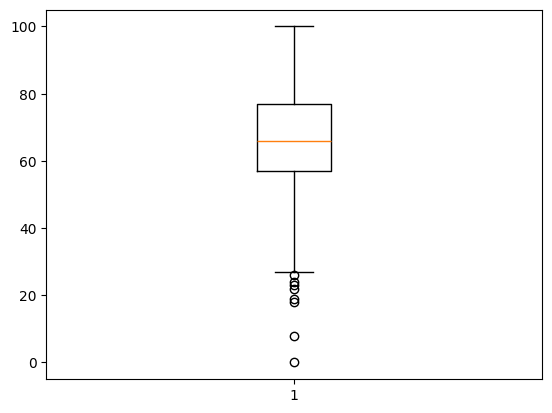

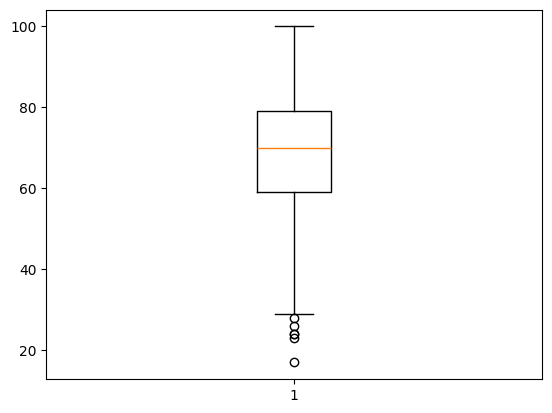

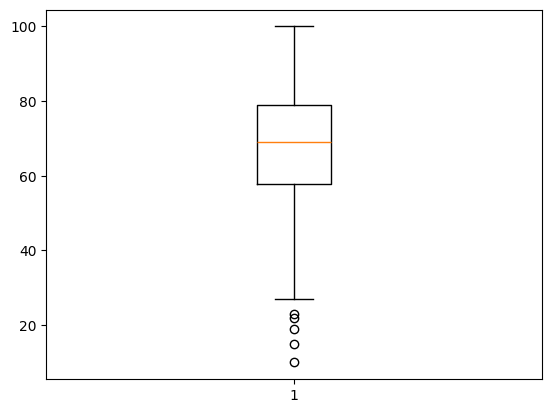

In [10]:
for col in df.columns:
    if df[col].dtype != 'object':
        plt.boxplot(x=df[col])
        plt.show()

In [11]:
df.shape

(1000, 8)

In [12]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [13]:
df.describe(include='object')

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course
count,1000,1000,1000,1000,1000
unique,2,5,6,2,2
top,female,group C,some college,standard,none
freq,518,319,226,645,642


Checking Numerical and categorical column

In [14]:
numeric_col = [feature for feature in df.columns if df[feature].dtype!='str']
categorical_col = [feature for feature in df.columns if df[feature].dtype=='str']

In [15]:
print("Numeric columns are:", numeric_col)
print("categorical columns are :",categorical_col)

Numeric columns are: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score']
categorical columns are : []


In [16]:
# num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# for col in num_cols:
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1

#     lower = Q1 - 1.5 * IQR
#     upper = Q3 + 1.5 * IQR

#     outliers = df[(df[col] < lower) | (df[col] > upper)]
#     df = df[(df[col] >= lower) & (df[col] <= upper)]

#     print(f"{col}: {len(outliers)} outliers")

In [17]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [18]:
df['TotalScore'] = df['math_score']+df['reading_score']+df['writing_score']
df['Avg_score'] = df['TotalScore'] /3

Student count who got full mark in subject

In [19]:
reading_full = df[df['reading_score']==100]['reading_score'].count()
writing_full = df[df['writing_score']==100]['writing_score'].count()
math_full = df[df['math_score']==100]['math_score'].count()
print(f"Number of students with full marks in reading: {reading_full}")
print(f"Number of students with full marks in writing: {writing_full}")
print(f"Number of students with full marks in math: {math_full}")

Number of students with full marks in reading: 17
Number of students with full marks in writing: 14
Number of students with full marks in math: 7


In [20]:
less_than_20_in_math = df[df['math_score'] <= 20]['math_score'].count()
less_than_20_in_reading = df[df['reading_score'] <= 20]['reading_score'].count()
less_than_20_in_writing = df[df['writing_score'] <= 20]['writing_score'].count()

print(f"Number of students with less than 20 marks in reading: {less_than_20_in_reading}")
print(f"Number of students with less than 20 marks in writing: {less_than_20_in_writing}")
print(f"Number of students with less than 20 marks in math: {less_than_20_in_math}")

Number of students with less than 20 marks in reading: 1
Number of students with less than 20 marks in writing: 3
Number of students with less than 20 marks in math: 4


In [21]:
# how many student are there who have less than 20 marks in any subject
less_than__or_equal_to_20 = df[(df['math_score'] <= 20) | (df['reading_score'] <= 20) | (df['writing_score'] <= 20)]
print(f"Number of students with less than or equal to 20 marks in any subject: {len(less_than__or_equal_to_20)}")

Number of students with less than or equal to 20 marks in any subject: 6


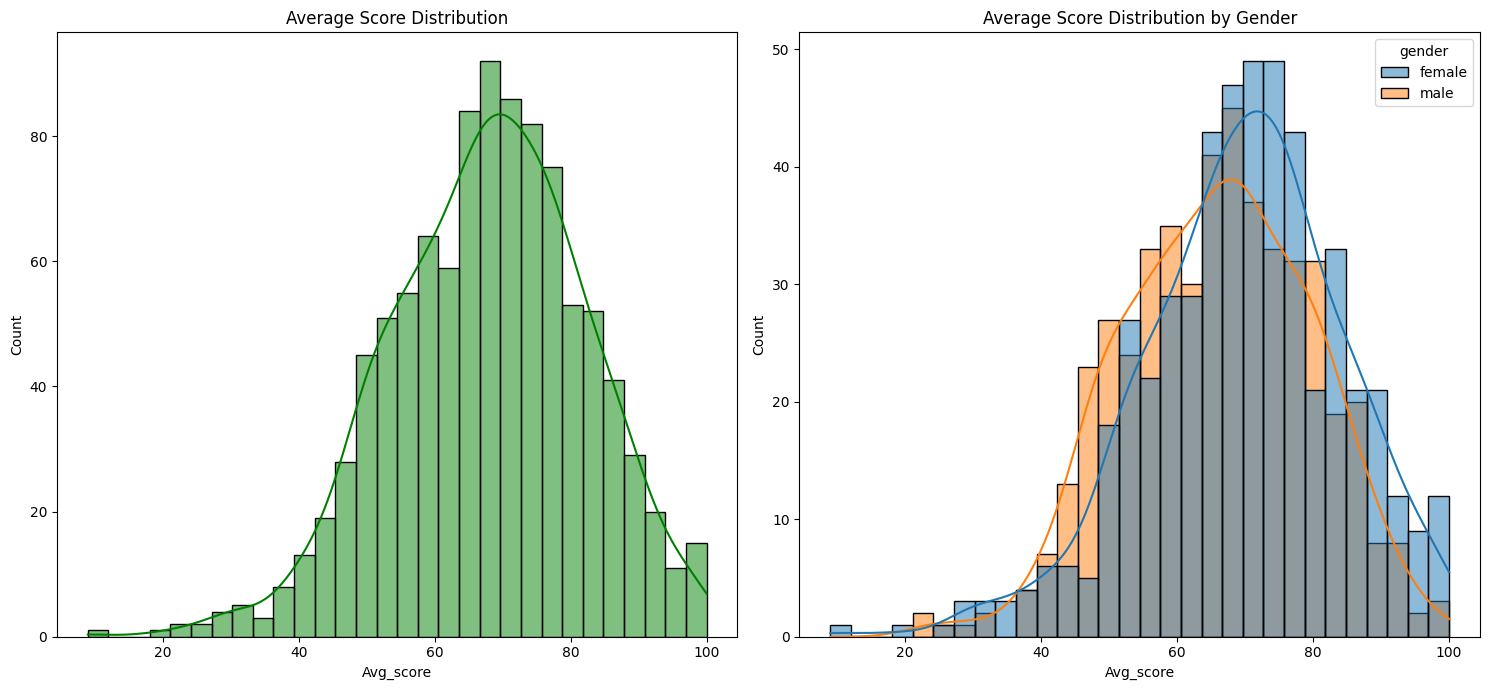

In [22]:
#Visualization of Average Score Distribution and Gender Effect
plt.subplots(1,2,figsize=(15,7))

plt.subplot(121)
sns.histplot(data=df,x='Avg_score',kde=True,color='green',bins=30)
plt.title("Average Score Distribution")

plt.subplot(122)
sns.histplot(data=df,x='Avg_score',kde=True,bins=30,hue='gender')
plt.title("Average Score Distribution by Gender")

plt.tight_layout()
plt.show()

# question : does gender affect the average score of students?
# answer : yes, female students have a higher average score than male students

Female perform well as compare to male student, so we can say that gender is also a factor the affect the average score of student

In [23]:
df.groupby(['gender','lunch'])['Avg_score'].mean().reset_index().sort_values(by='Avg_score',ascending=False)

,gender,lunch,Avg_score
1,female,standard,73.219858
3,male,standard,68.356540
0,female,free/reduced,63.215168
2,male,free/reduced,61.042169


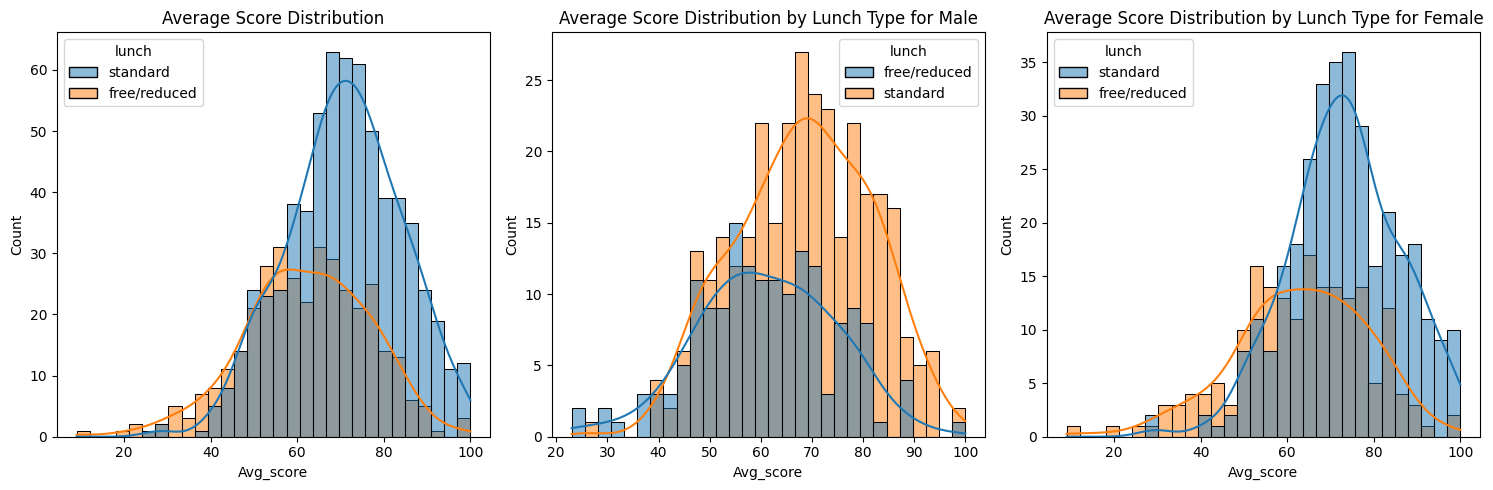

In [24]:
#Visualization of Average Score Distribution and Gender Effect
plt.subplots(1,3,figsize=(15,5))

plt.subplot(131)
sns.histplot(data=df,x='Avg_score',kde=True,color='green',bins=30,hue='lunch')
plt.title("Average Score Distribution")

plt.subplot(132)
sns.histplot(data=df[df.gender=='male'],x='Avg_score',kde=True,bins=30,hue='lunch')
plt.title("Average Score Distribution by Lunch Type for Male")

plt.subplot(133)
sns.histplot(data=df[df.gender=='female'],x='Avg_score',kde=True,bins=30,hue='lunch')
plt.title("Average Score Distribution by Lunch Type for Female")


plt.tight_layout()
plt.show()

The lunch type effects the average score.
The person who take standard lunch score well as compare the one who take free/reduced lunch

In [25]:
df.groupby(['gender','parental_level_of_education'])['Avg_score'].mean().reset_index().sort_values(by='Avg_score',ascending=False).reset_index()

,index,gender,parental_level_of_education,Avg_score
0,1,female,bachelor's degree,74.671958
1,3,female,master's degree,73.648148
2,9,male,master's degree,73.521739
3,0,female,associate's degree,71.123563
4,4,female,some college,71.002825
5,7,male,bachelor's degree,68.775758
6,6,male,associate's degree,67.867925
7,10,male,some college,65.716049
8,5,female,some high school,65.564103
9,2,female,high school,64.748227


In [26]:
df.groupby('gender')['Avg_score'].count()

gender
female    518
male      482
Name: Avg_score, dtype: int64

In [27]:
import seaborn as sns

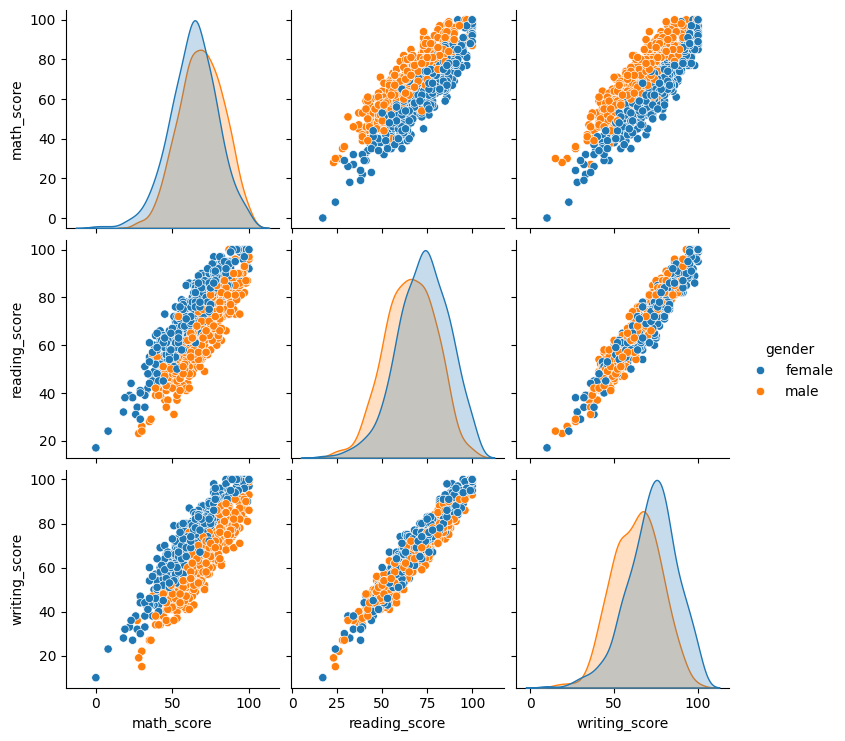

In [28]:
sns.pairplot(data=df,vars=['math_score','reading_score','writing_score'],hue='gender')
plt.show()

In [29]:
# relationship between all columns:
# ANSWER: THE RELATIONSHIP BETWEEN ALL COLUMNS IS STRONG AS THEY ARE ALL RELATED TO STUDENT PERFORMANCE AND SCORES.THE CATEGORICAL VARIABLES LIKE GENDER, LUNCH, TEST PREPARATION COURSE, AND PARENTAL LEVEL OF EDUCATION CAN AFFECT THE STUDENT'S PERFORMANCE AND SCORES. THE NUMERICAL VARIABLES LIKE MATH SCORE, READING SCORE, WRITING SCORE, TOTAL SCORE, AND AVERAGE SCORE ARE ALL INTERRELATED AND CAN BE USED TO ANALYZE THE STUDENT'S PERFORMANCE.
score_cols = ['math_score', 'reading_score', 'writing_score']

In [30]:
df.groupby('gender')[score_cols].mean()

,math_score,reading_score,writing_score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


In [31]:
for column in score_cols:
    print("\n",column)
    print("minimum value of", column, "is", df[column].min())
    print("maximum value of", column, "is", df[column].max())
    print("mean value of", column, "is", df[column].mean())


 math_score
minimum value of math_score is 0
maximum value of math_score is 100
mean value of math_score is 66.089

 reading_score
minimum value of reading_score is 17
maximum value of reading_score is 100
mean value of reading_score is 69.169

 writing_score
minimum value of writing_score is 10
maximum value of writing_score is 100
mean value of writing_score is 68.054


In [32]:
df[score_cols].describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [33]:
average_score = df[score_cols].mean().sort_values(ascending=False)
print(average_score)

reading_score    69.169
writing_score    68.054
math_score       66.089
dtype: float64


In [34]:
preparation_analysis = df.groupby("test_preparation_course")[score_cols].mean()

print("\n========== TEST PREPARATION ANALYSIS ==========")

print(preparation_analysis)


========== TEST PREPARATION ANALYSIS ==========
                         math_score  reading_score  writing_score
test_preparation_course                                          
completed                 69.695531      73.893855      74.418994
none                      64.077882      66.534268      64.504673


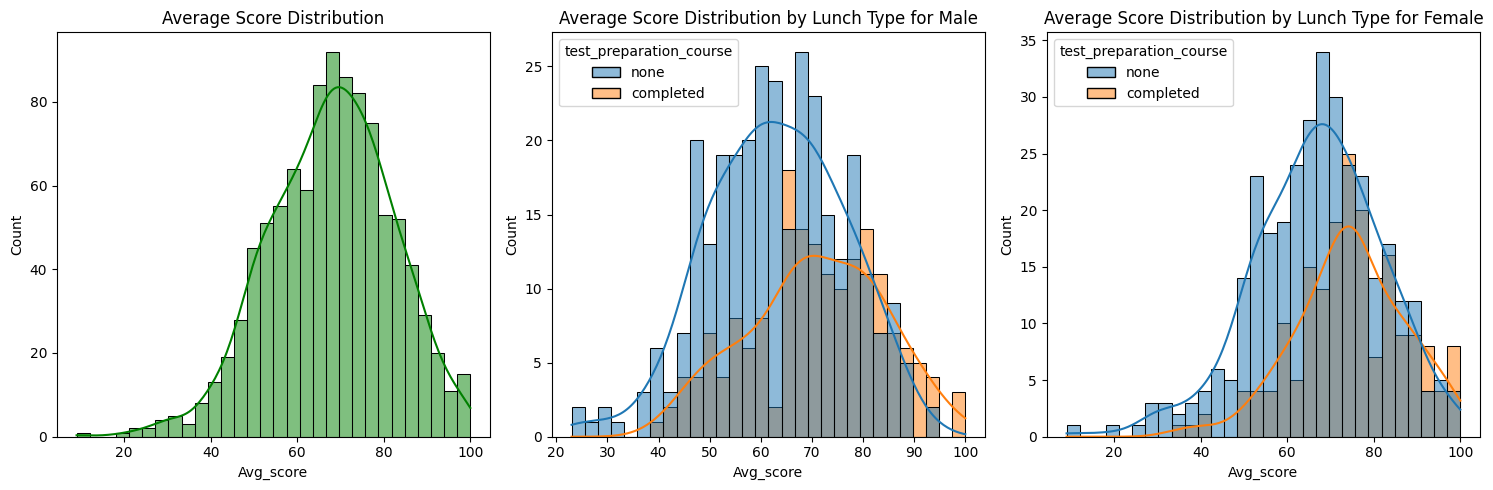

In [35]:
plt.subplots(1,3,figsize=(15,5))

plt.subplot(131)
sns.histplot(data=df,x='Avg_score',kde=True,color='green',bins=30)
plt.title("Average Score Distribution")

plt.subplot(132)
sns.histplot(data=df[df.gender=='male'],x='Avg_score',kde=True,bins=30,hue='test_preparation_course')
plt.title("Average Score Distribution by Lunch Type for Male")

plt.subplot(133)
sns.histplot(data=df[df.gender=='female'],x='Avg_score',kde=True,bins=30,hue='test_preparation_course')
plt.title("Average Score Distribution by Lunch Type for Female")

plt.tight_layout()
plt.show()

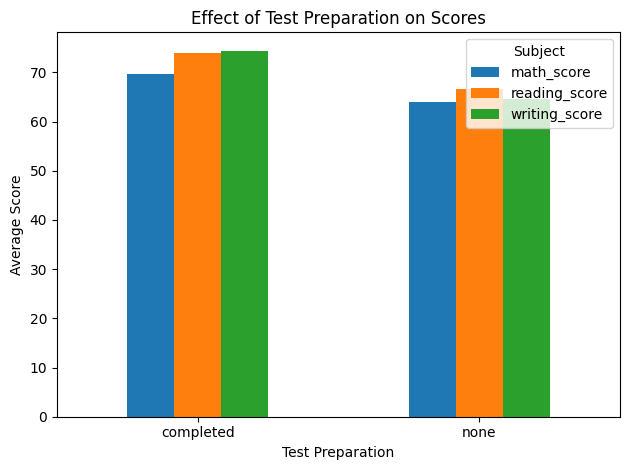

In [36]:
preparation_analysis.plot(kind='bar')
plt.title("Effect of Test Preparation on Scores")

plt.xlabel("Test Preparation")

plt.ylabel("Average Score")

plt.xticks(rotation=0)

plt.legend(title="Subject")

plt.tight_layout()

plt.show()

<Axes: xlabel='gender,race_ethnicity'>

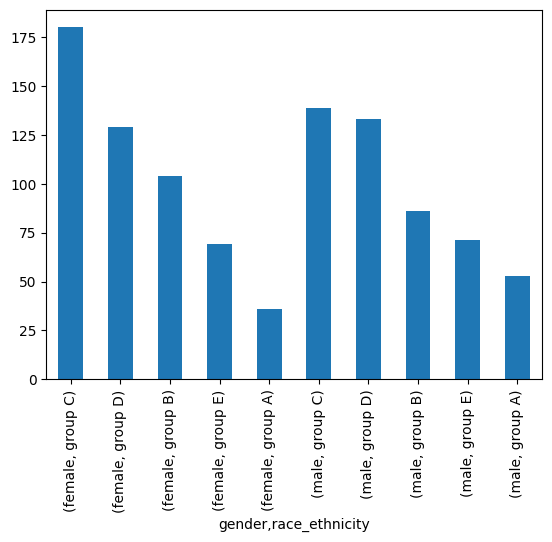

In [37]:
# race_ethinicity_by_gender
race_ethnicity_by_gender  = df.groupby('gender')['race_ethnicity'].value_counts()
race_ethnicity_by_gender.plot(kind='bar')

# the highest no of student belong to group C

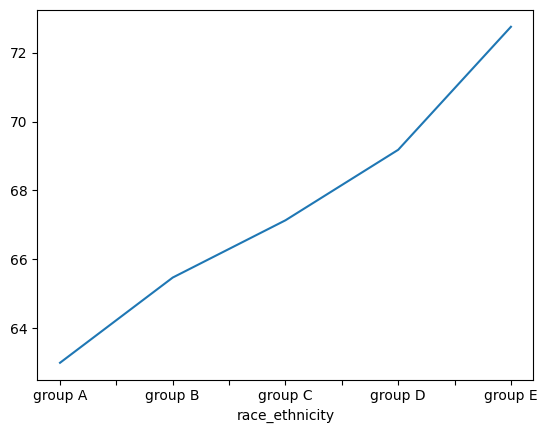

In [38]:
# Calculate average score for each race/ethnicity
race_avg = df.groupby("race_ethnicity")["Avg_score"].mean()

# Create bar chart
race_avg.plot(kind="line")
plt.show()

Finding: The average student score varies across race/ethnicity groups. Group E has the highest average score of approximately 72.75, while Group A has the lowest at approximately 62.99, giving a difference of about 9.76 points
This analysis identifies an association between race/ethnicity and average score in this dataset; it does not establish that race/ethnicity itself causes differences in academic performance. Other factors such as parental education, lunch status, and test preparation may also contribute.

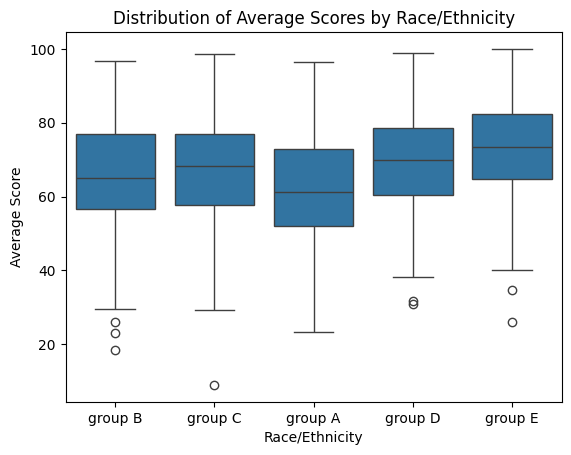

In [39]:
# Create box plot
sns.boxplot(
    data=df,
    x="race_ethnicity",
    y="Avg_score"
)

plt.title("Distribution of Average Scores by Race/Ethnicity")
plt.xlabel("Race/Ethnicity")
plt.ylabel("Average Score")

plt.show()

<Axes: ylabel='parental_level_of_education'>

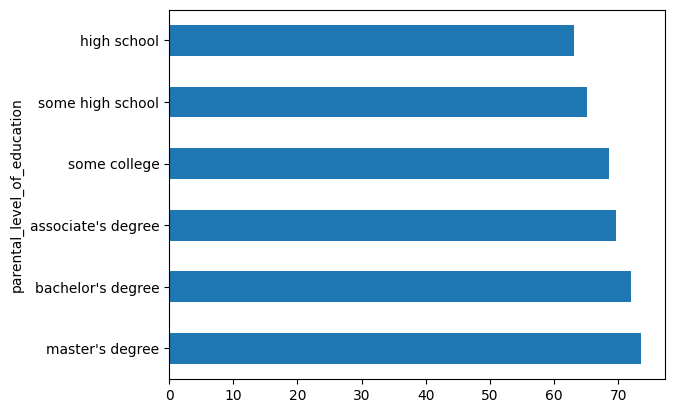

In [40]:
parental_analysis=  df.groupby("parental_level_of_education")['Avg_score'].mean().round(2).sort_values(ascending=False)
parental_analysis.plot(kind='barh')

Generally, higher parental education is associated with better student performance.

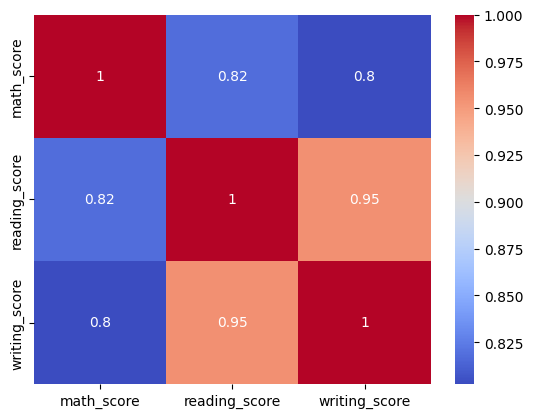

In [41]:
corr = df[score_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

Students who perform well in Reading tend to perform well in Writing.

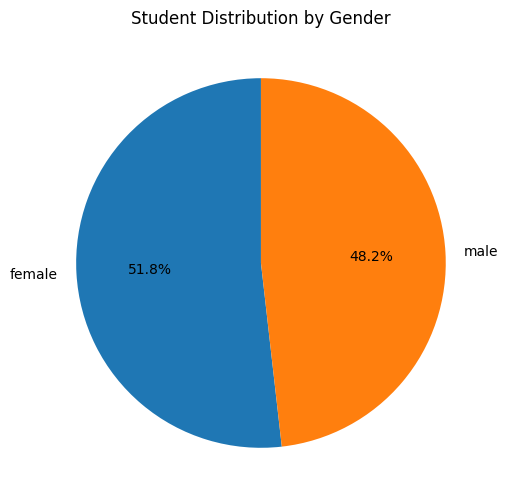

In [42]:
# Count students in each gender category
gender_count = df["gender"].value_counts()

# Create pie chart
plt.figure(figsize=(6, 6))

plt.pie(
    gender_count.values,
    labels=gender_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Student Distribution by Gender")

plt.show()

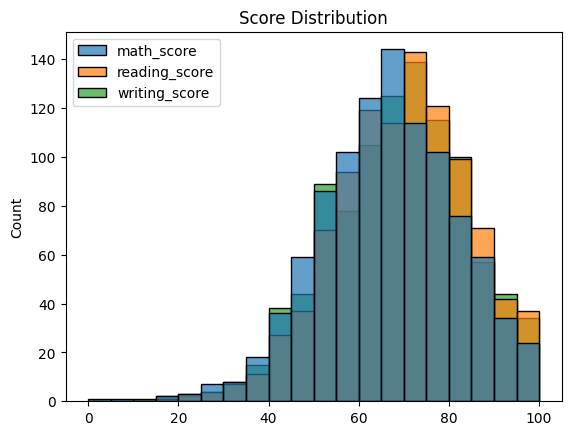

In [43]:
# df[score_cols].plot(
#     kind="hist",
#     bins=20,
#     alpha=0.7,
#     figsize=(10, 6)
# )
sns.histplot(df[score_cols],
    bins=20,
    alpha=0.7,
)
plt.title("Score Distribution")
plt.show()

In [44]:
# ==========================================
# PASS ANALYSIS
# ==========================================

# Assuming 40 is passing in each subject

df["passed_all"] = (
    (df["math_score"] >= 40) &
    (df["reading_score"] >= 40) &
    (df["writing_score"] >= 40)
)

print(
    "Students passing all subjects:",
    df["passed_all"].sum()
)

print(
    "Pass percentage:",
    df["passed_all"].mean() * 100
)

Students passing all subjects: 949
Pass percentage: 94.89999999999999


lunch         test_preparation_course
free/reduced  completed                  67.76
              none                       58.95
standard      completed                  75.51
              none                       68.30
Name: Avg_score, dtype: float64


<Axes: xlabel='lunch,test_preparation_course'>

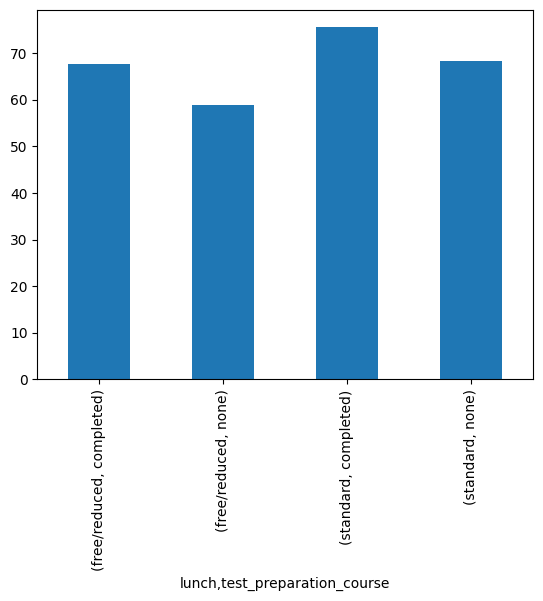

In [45]:
# =========================================
# LUNCH + PREPARATION
# ==========================================

result = (
    df.groupby(
        ["lunch", "test_preparation_course"]
    )["Avg_score"]
    .mean()
    .round(2)
)

print(result)

result.plot(kind="bar")

Student who have completed the test and have standard lunch perform better than student who have not complete the test and have free/reduced lunch
There is a big difference approximately 75.51-58.95 = 16 point approx

Text(0.5, 1.0, 'Average Score of Students')

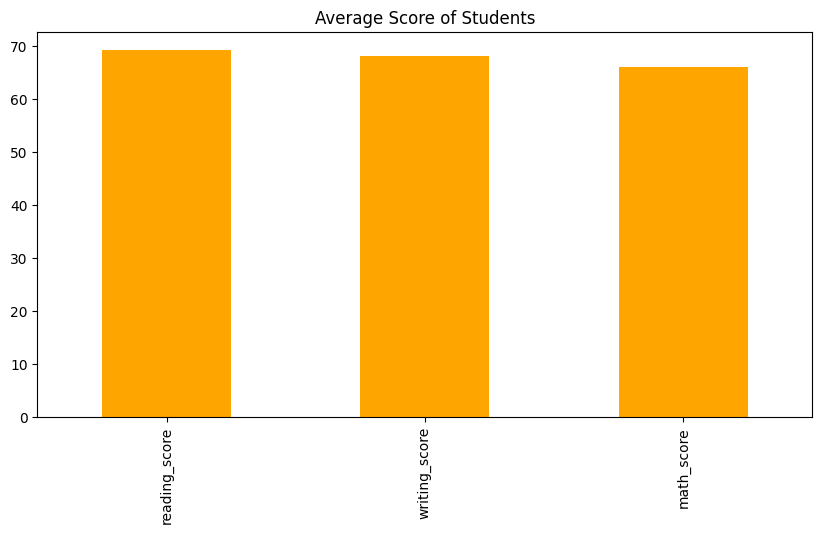

In [46]:
average_score.plot(kind='bar',figsize=(10,5),color = 'orange')
plt.title("Average Score of Students")


In [47]:
gender_analysis = df.groupby('gender')[score_cols].mean()
print(gender_analysis)

        math_score  reading_score  writing_score
gender                                          
female   63.633205      72.608108      72.467181
male     68.728216      65.473029      63.311203


# The dataset suggests that student performance is not driven by one variable. It reflects a combination of preparation, lunch category, parental education, group differences, and subject-specific patterns

In [48]:
(df[score_cols] >= 75).all(axis=1).mean() * 100

np.float64(21.099999999999998)

In [49]:
# math_score vs Avg_score on the basis of gender

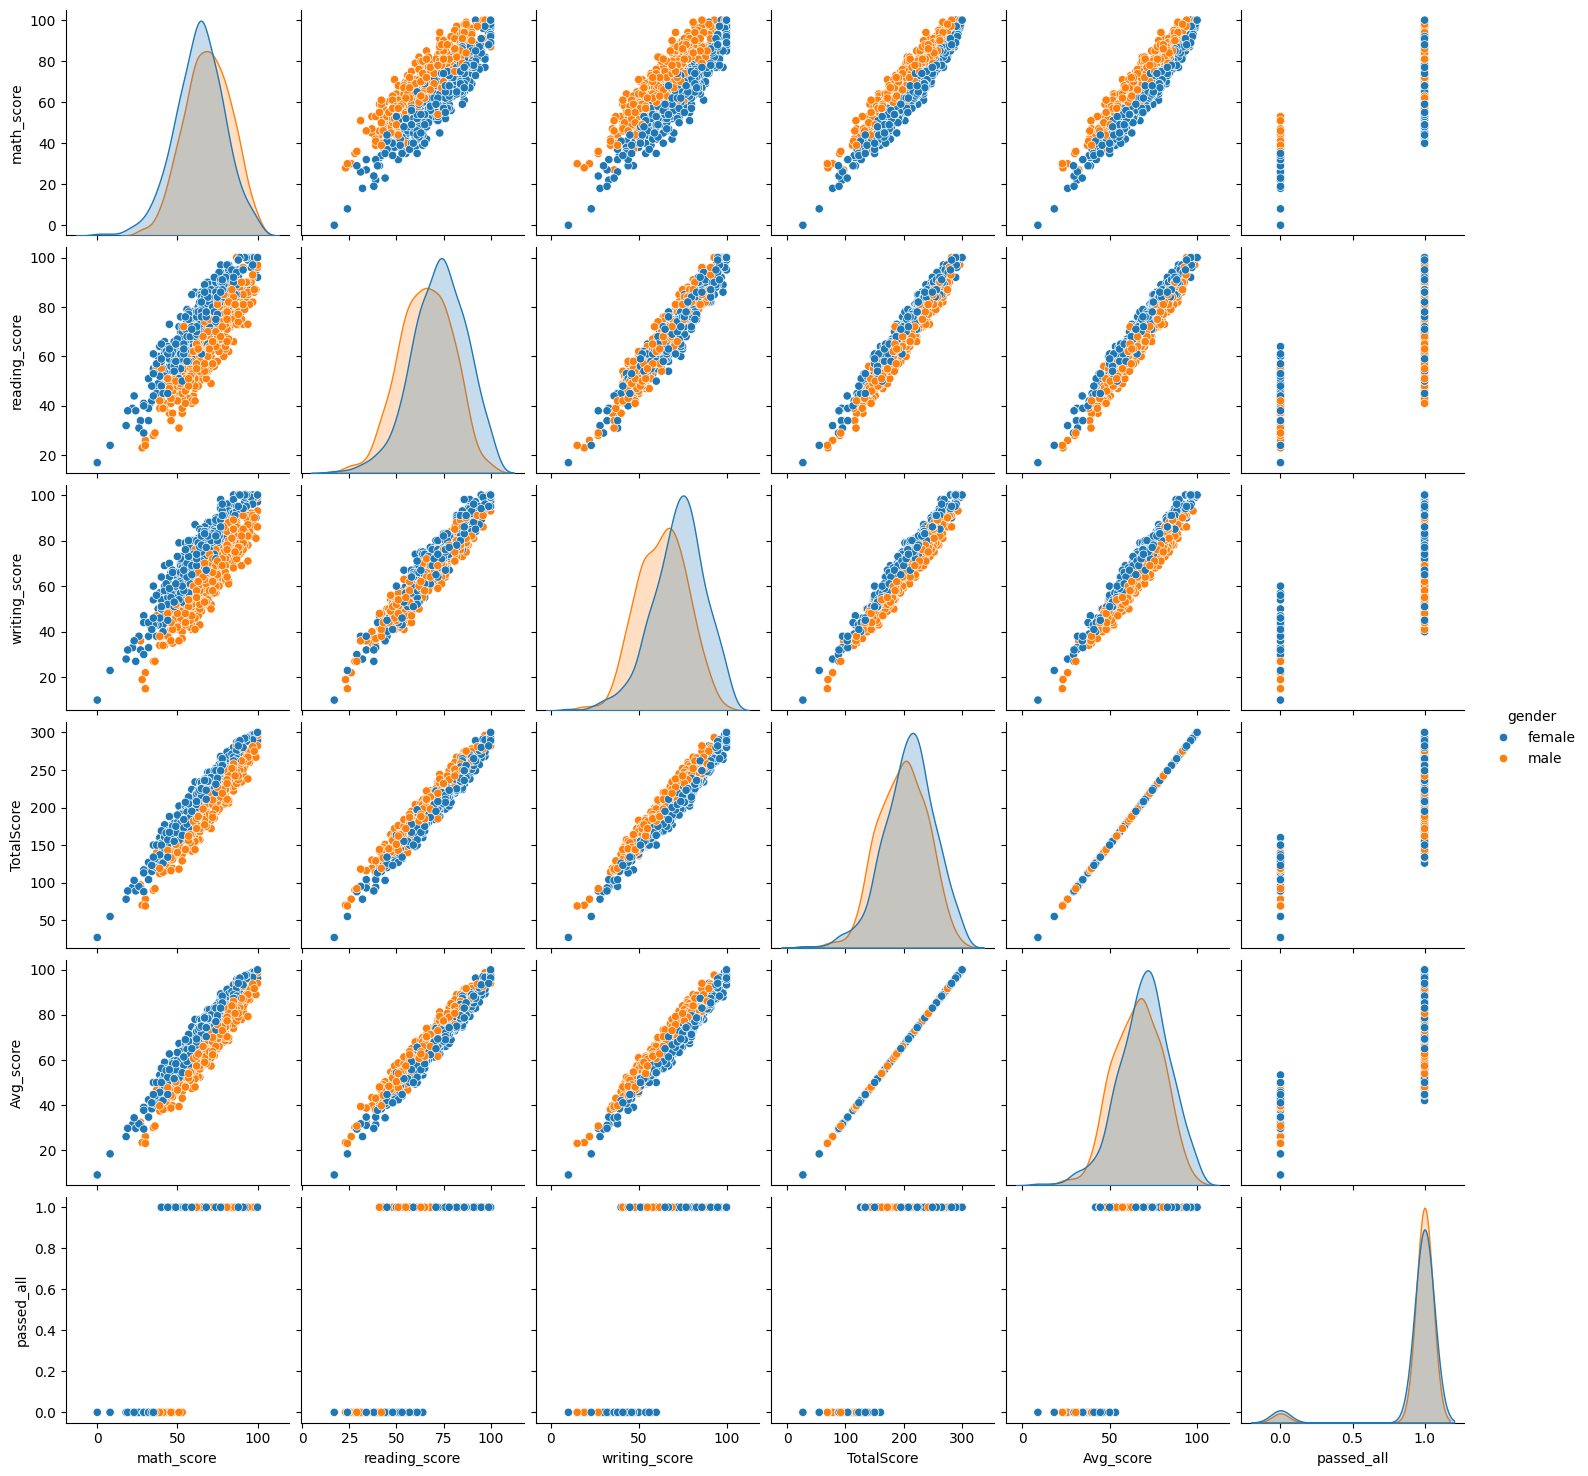

In [50]:
sns.pairplot(df,hue='gender')
plt.show()